# DREAMS - Concentrated PV Volt/VAR and Storage 


In [1]:
import dreams
from pathlib import Path


import matplotlib.dates as mdates
import matplotlib
import os

In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'

output_dir = model_dir / 'temp_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
feeder = dreams.Feeder(model_dir/'Main.dss', name='sfo_p1udt1469')


# identifying single location and connected line
for system location and control monitoring

In [4]:
is_hv = feeder.loads['primary']
feeder.loads[~is_hv].sort_values('kw', ascending=False).head(3)

,phases,kv,kw,kvar,pf,conn,bus1,model,status,short_bus1,bus1_nodes,bus1_phase,primary
name,,,,,,,,,,,,,
load_p1ulv1823,3,0.48,182.005355,45.372107,0.970304,wye,p1ulv1823.1.2.3,1,Variable,p1ulv1823,123,ABC,False
load_p1ulv12,3,0.48,126.295055,37.876880,0.957851,wye,p1ulv12.1.2.3,1,Variable,p1ulv12,123,ABC,False
load_p1ulv1669,3,0.48,79.823119,9.828634,0.992505,wye,p1ulv1669.1.2.3,1,Variable,p1ulv1669,123,ABC,False


In [5]:
single_location = feeder.loads[~is_hv].sort_values('kw', ascending=False).iloc[0]
single_location

phases                      3
kv                       0.48
kw                 182.005355
kvar                45.372107
pf                   0.970304
conn                      wye
bus1          p1ulv1823.1.2.3
model                       1
status               Variable
short_bus1          p1ulv1823
bus1_nodes                123
bus1_phase                ABC
primary                 False
Name: load_p1ulv1823, dtype: object

In [6]:
service_line = (feeder.lines['short_bus2'] == single_location['short_bus1']) \
    | (feeder.lines['short_bus1'] == single_location['short_bus1'])

feeder.lines[service_line]

,phases,normamps,emergamps,length,units,wires,spacing,linecode,geometry,bus1,bus2,linetype,totalcust,short_bus1,short_bus2,kv_base_1,primary_1,kv_base_2,primary_2
name,,,,,,,,,,,,,,,,,,,
l(r:p1udt429lv-p1ulv1823),3,550.0,600.0,0.009016,km,[],,3p_ug_al_750kcmil_3_1,,p1udt429lv.1.2.3,p1ulv1823.1.2.3,oh,1,p1udt429lv,p1ulv1823,0.277128,False,0.277128,False


In [7]:
# line feeding single location should be used to control storage
line_to_monitor = feeder.lines[service_line].index[0]
feeder.lines.loc[line_to_monitor]

phases                            3
normamps                      550.0
emergamps                     600.0
length                     0.009016
units                            km
wires                            []
spacing                            
linecode      3p_ug_al_750kcmil_3_1
geometry                           
bus1               p1udt429lv.1.2.3
bus2                p1ulv1823.1.2.3
linetype                         oh
totalcust                         1
short_bus1               p1udt429lv
short_bus2                p1ulv1823
kv_base_1                  0.277128
primary_1                     False
kv_base_2                  0.277128
primary_2                     False
Name: l(r:p1udt429lv-p1ulv1823), dtype: object

# adding qsts profiles

## demand data
loading and identifying max day

Text(0.5, 0, '15 Minute Interval')

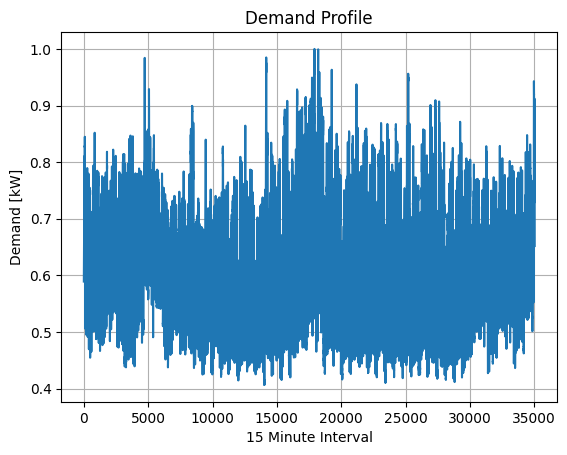

In [8]:
demand_fp = model_dir / 'pu_substation_demand.csv'

demand_shape = dreams.Shape(demand_fp, 'demand_profile', column=0, hour_interval=15/60)

ax = (demand_shape.data).plot()
ax.grid()
ax.set_axisbelow(True)
ax.set_title('Demand Profile')
ax.set_ylabel('Demand [kW]')
ax.set_xlabel('15 Minute Interval')

Locating timestep surrounding max demand day and crating range for plot

In [ ]:
max_demand_ts = demand_shape.data.idxmax()
max_demand_ts

max_day = int(max_demand_ts / (24 * 4))


In [10]:
max_demand_ts

17923

In [ ]:
start_index = (max_day-1)*(4*24)
end_index = start_index + 3*4*24

(17760.0, 18048.0)

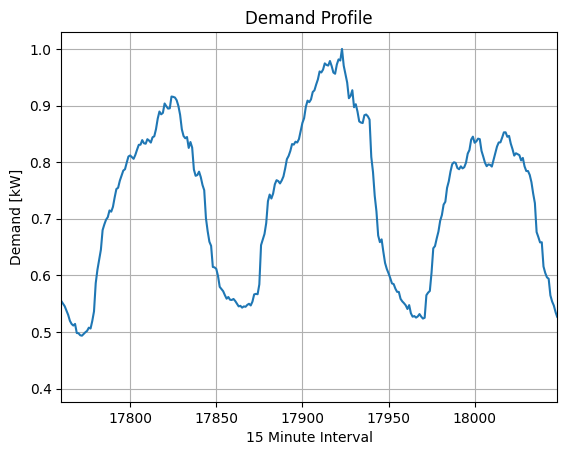

In [12]:

ax = (demand_shape.data).plot()
ax.grid()
ax.set_axisbelow(True)
ax.set_title('Demand Profile')
ax.set_ylabel('Demand [kW]')
ax.set_xlabel('15 Minute Interval')
ax.set_xlim([start_index, end_index])

Text(0.5, 0, '15 Minute Interval')

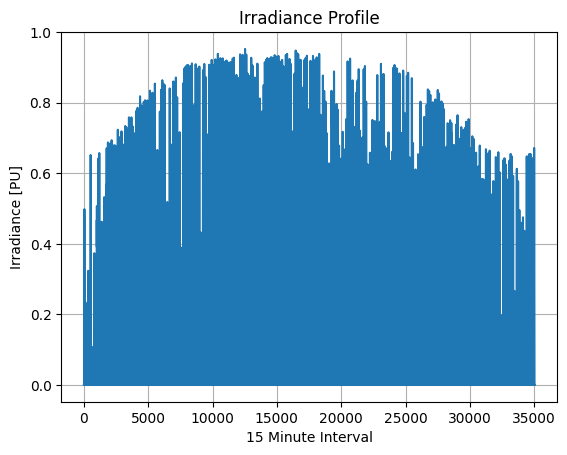

In [13]:
irradiance_fp = model_dir / 'pu_irradiance.csv'

irradiance_shape = dreams.Shape(irradiance_fp, 'irradiance_profile', column=0, hour_interval=15/60)

ax = irradiance_shape.plot()
ax.grid()
ax.set_axisbelow(True)
ax.set_title('Irradiance Profile')
ax.set_ylabel('Irradiance [PU]')
ax.set_xlabel('15 Minute Interval')

(17760.0, 18048.0)

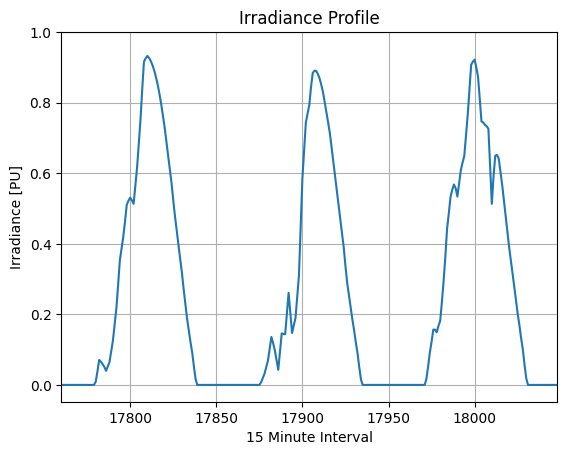

In [14]:
ax = irradiance_shape.plot()
ax.grid()
ax.set_axisbelow(True)
ax.set_title('Irradiance Profile')
ax.set_ylabel('Irradiance [PU]')
ax.set_xlabel('15 Minute Interval')
ax.set_xlim([start_index, end_index])

# qsts scenario creation

In [15]:


qsts_scenario = dreams.hc.Scenario(
    name='QSTS Concentrated PV and Storage with Control',
    feeder=feeder,
    n_simulations=1,  # single location
    n_steps=5,
    qsts_step_size_sec = 60*60,  # x one hour timestep.
    duration_seconds = 3*24*60*60, # three day sim
    qsts_hour_offset=start_index,
    max_control_iterations=1000
    #step_title='PV [MW]',
    #step_labels=step_labels
)

## adding shapes
shapes are added to th bse redirects
and loads altered to follow demand shape

In [16]:
# add demand profile redirect scenario
qsts_scenario.base_redirects.append(demand_shape.create_shape_redirect(use_file=False))

# apply demand profile to all loads
qsts_scenario.base_redirects.append(demand_shape.create_edit_elements_redirect(feeder))

# add irradiance profile to base redirects
qsts_scenario.base_redirects.append(irradiance_shape.create_shape_redirect(use_file=False))

# inverter control

This control applies to all pv inverters that have control listed as 'default_vv',
which is added to the pv allocation as a control rule.

Additional parameters can be added to the InverterControl that describe the 
control type:
* vv (volt/var) 
* vw (volt/watt)
* vv_vw (both volt var and volt watt)

Note: in this case, vv_vw conflicts with the storage action at the single location
as both controls deal with real power - so, for this reason, only vv is shown here.

More information can be found in the InverterControl.py class file.

In [17]:
# creating inverter control, adding to definition to control redirects
inverter_control = dreams.InverterControl(name='default_vv', kind='vv')  
qsts_scenario.add_control_redirect(inverter_control.create_control_redirect())

# pv allocation

In [18]:
allocation = dreams.hc.Allocation(feeder, name='Concentrated PV')
concentrated_max_pv = 1000  # kw

# create pv allocation element
stepeed_pv = dreams.hc.PhotovoltaicAllocationElement(
    'Concentrated Location',
    element_prepend='added_pv_',
    element_kva=concentrated_max_pv/qsts_scenario.n_steps,
    total_kva=concentrated_max_pv,
    kind='total',
    element_kv=single_location['kv']/1.732,
)
allocation.add_allocation_element(stepeed_pv)

allocation.add_location_rule(
    'Single Location',
    feeder_element_class='loads',
    element_attribute='short_bus1',
    comparison_operation='==',
    comparison_value=single_location.short_bus1,
    )

allocation.add_shape_rule(kind='yearly', name='irradiance_profile')

# adding control rule to  pv allocation
allocation.add_control_rule('default_vv')

qsts_scenario.add_allocation(allocation)


# storage control

This storage control monitors the flow on the given element, to achieve
peak shave high and low whil allowing some export.

Again, further information can be found in the StorageControl class definition
or in the openDSS documentation as the class accomodates for variable keywords
to be passed to the resulting dss defintion.

Note: the max_ctrl_iter value is very large to allow the control actions to 
complete - this may not be required all the times.


In [19]:
storage_controller = dreams.StorageControl(
    name='storage_control',
    element=f'line.{line_to_monitor}',
    kwtarget=50,  # manage peak draw
    kwtargetlow=-25,  # handle pv export... if set to 100 over loading...  # because of averages? 3 phase monitor?
    resetlevel=0.20,  # minimum soc to allow discharge
    inhibittime=1.0,
    max_ctrl_iter=1000,
    eventlog='yes',
    monphase='min'  # should it be min? defaults to ave..
    )  

# add storage controller to scenario base redirects (comment out below to NOT add storage control)
qsts_scenario.add_control_redirect(storage_controller.create_control_redirect())

## storage allocation
ratio of pv to storage


In [20]:
storage_to_pv = 2.0

per_step_storage = concentrated_max_pv/qsts_scenario.n_steps * storage_to_pv

each_step_storage = [x*per_step_storage for x in range(0,qsts_scenario.n_steps+1)]

In [21]:
each_step_storage

[0.0, 400.0, 800.0, 1200.0, 1600.0, 2000.0]

In [22]:
storage_allocation_obj = dreams.hc.Allocation(feeder, name='Centralized Storage')


storage_to_add = dreams.hc.StorageAllocationElement(
    'Concentrated Storage',  # this is the name, or reference, to the allocation element
    element_prepend= f'new_storage_', 
    element_kva= 50, 
    element_kwh= 150,
    total_kva= each_step_storage,
    element_stored = 20,
    kind= 'each_step'
)

storage_allocation_obj.add_allocation_element(storage_to_add)

# add location rule for allocation
storage_allocation_obj.add_location_rule(
    'single location',
    feeder_element_class='loads',
    element_attribute='short_bus1',
    comparison_operation='==',
    comparison_value=single_location.short_bus1,
    )

storage_allocation_obj.add_control_rule('storage_control')

# add allocation to scenario
qsts_scenario.add_allocation(storage_allocation_obj)

# run simulation

In [23]:
qsts_scenario.write_steps()  
qsts_scenario.run()


Started QSTS Simulation
Started Simulation Seed 0
Started Simulation Step 0
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 1
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 2
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 3
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 4
QSTS Step 73/73  (100.00% complete)  
Started Simulation Step 5
QSTS Step 73/73  (100.00% complete)  
, 5
Completed Seed: 0
Finished all Seeds


C:\Users\jthaine\AppData\Roaming\Python\Python310\site-packages\xarray\core\concat.py:546: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


Note that non-converged steps will be identified here - this could be for a wide variety of reasons.

Typically, non-converging simulations are not believable or could indicate a very serious system flaw

In [24]:
# dreams.dss.cmd('show eventlog')  # this will show the event log for control action

maybe something about how QSTS results are stored? 

monitors, group results...

result export

In [25]:
qsts_scenario.results.export_results()  # allows for later results analysis

['models\\sfo_p1udt1469\\QSTS_scenarios\\QSTS Concentrated PV and Storage with Control\\results\\qsts_concentrated_pv_and_storage_with_control_general_results_seed_0.xlsx',
 'models\\sfo_p1udt1469\\QSTS_scenarios\\QSTS Concentrated PV and Storage with Control\\results\\qsts_concentrated_pv_and_storage_with_control_general_results_aggregate.xlsx']

# results

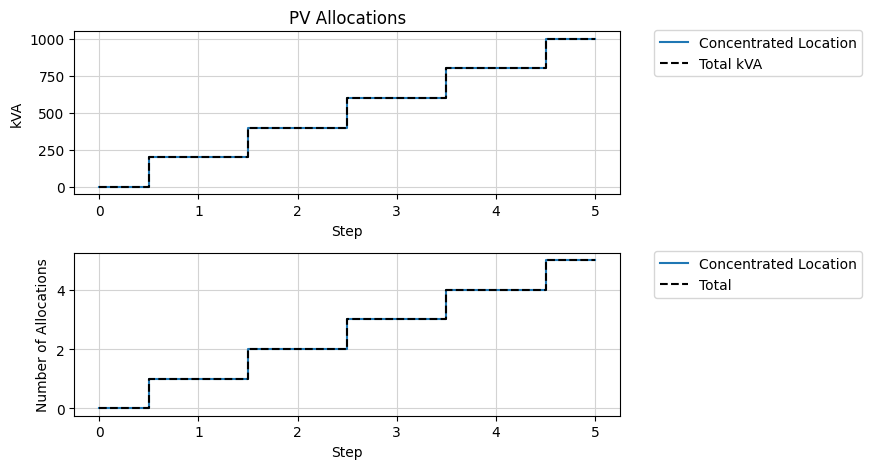

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'PV Allocations'}, xlabel='Step', ylabel='kVA'>,
  <Axes: xlabel='Step', ylabel='Number of Allocations'>])

In [26]:
# to ensure propoper allocation
qsts_scenario.seed_results[0].plot(kind='pv_allocation')

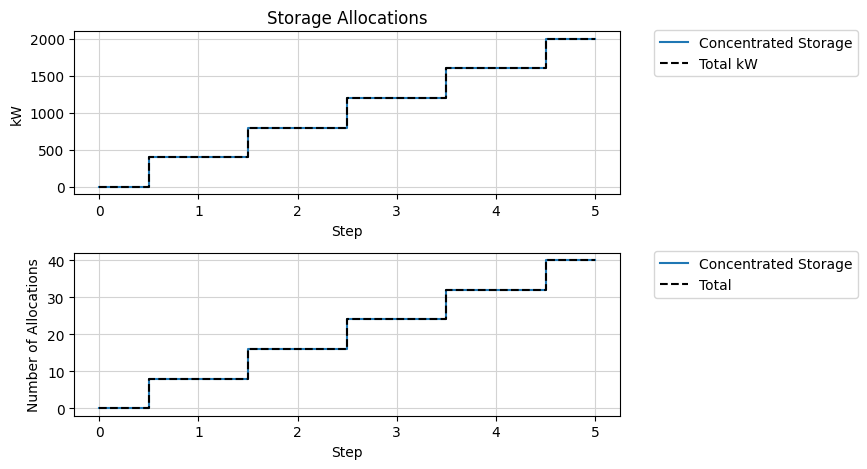

(<Figure size 640x480 with 2 Axes>,
 [<Axes: title={'center': 'Storage Allocations'}, xlabel='Step', ylabel='kW'>,
  <Axes: xlabel='Step', ylabel='Number of Allocations'>])

In [27]:
# to ensure propper allocation
qsts_scenario.seed_results[0].plot(kind='storage_allocation')

# TODO Modify for single ax, update labels.

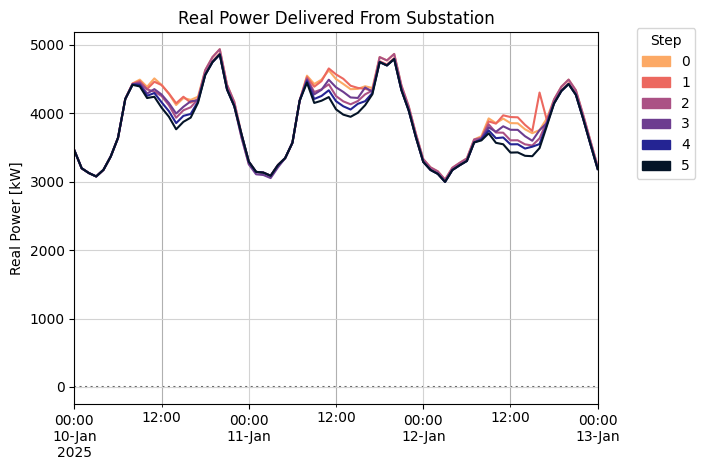

In [28]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='p', use_dt=True)



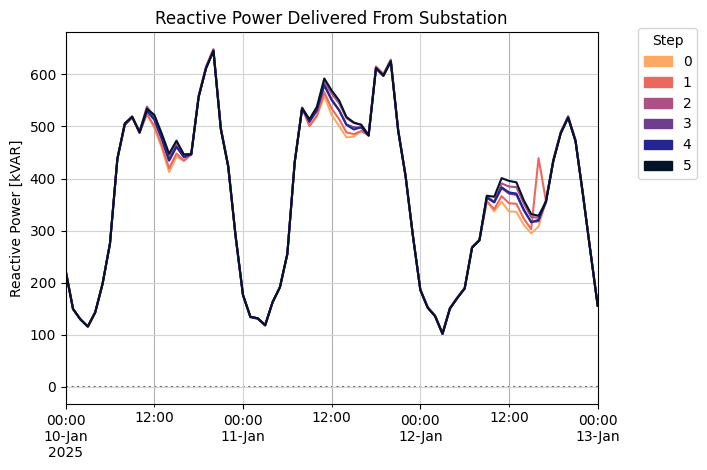

In [29]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='q', use_dt=True)

Text(0.5, 1.0, 'Primary Maximum and Minimum Voltages')

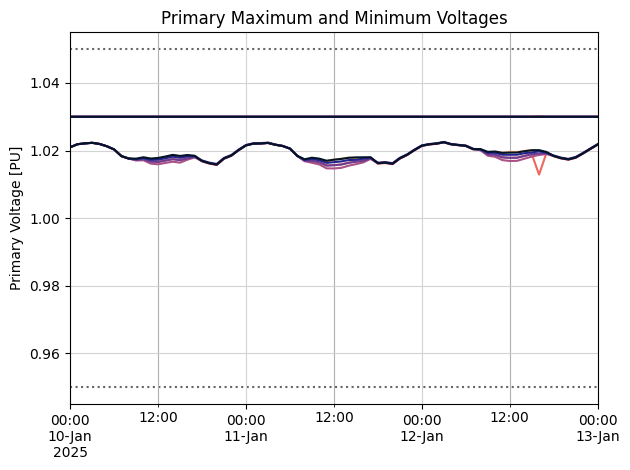

In [30]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='voltage', use_dt=True, legend=False)
ax.set_title('Primary Maximum and Minimum Voltages')

Text(0.5, 1.0, 'Secondary Maximum and Minimum Voltages')

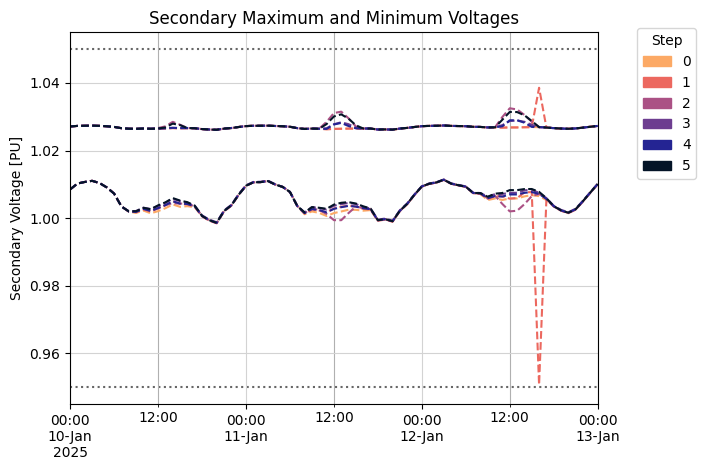

In [31]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='voltage', use_dt=True, primary=False, legend=True)
ax.set_title('Secondary Maximum and Minimum Voltages')

Text(0.5, 1.0, 'Maximum Used Capacity of System Lines\n(dashed=secondary)')

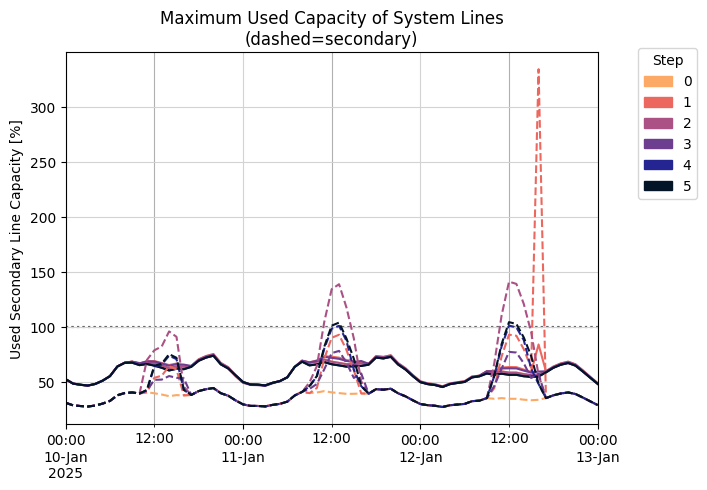

<Figure size 640x480 with 0 Axes>

In [32]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='line', primary=True, use_dt=True)
qsts_scenario.seed_results[0].plot(kind='line', primary=False, legend=True, use_dt=True, ax=ax)
ax.set_title('Maximum Used Capacity of System Lines\n(dashed=secondary)')

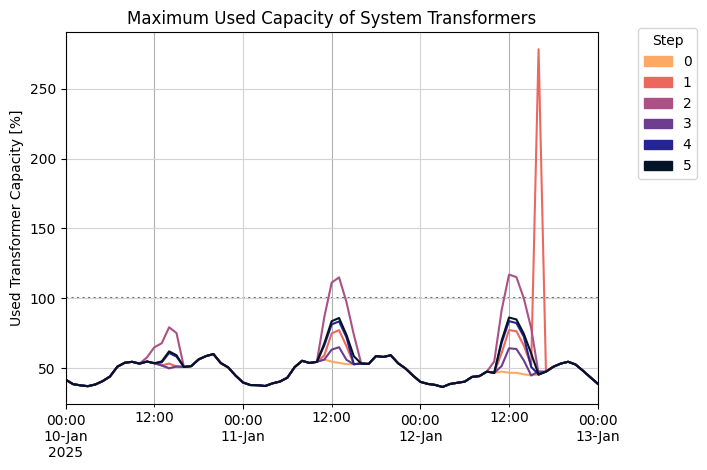

In [33]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='transformer', use_dt=True)

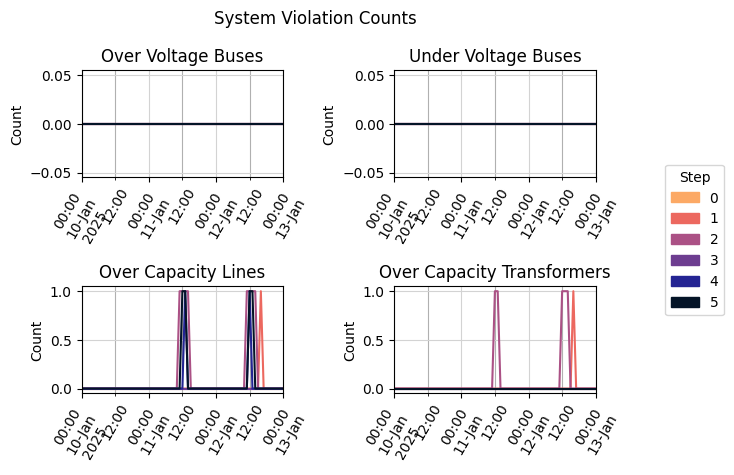

In [34]:
fig, axes = qsts_scenario.seed_results[0].plot(kind='violations', use_dt=True, as_percent=False)

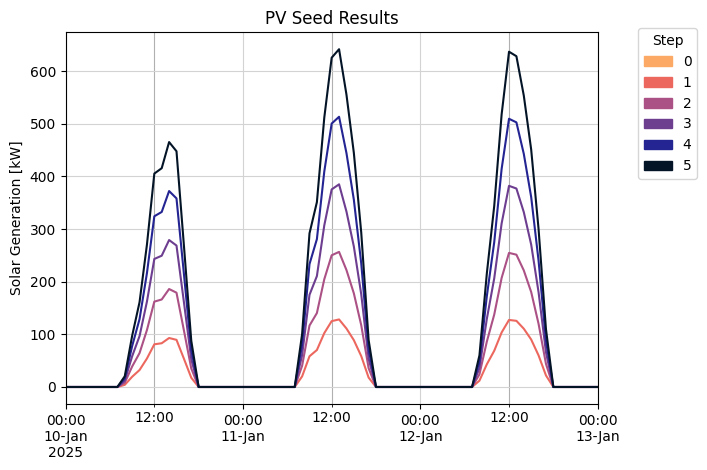

In [35]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='pv_p', use_dt=True, legend_outside=True)


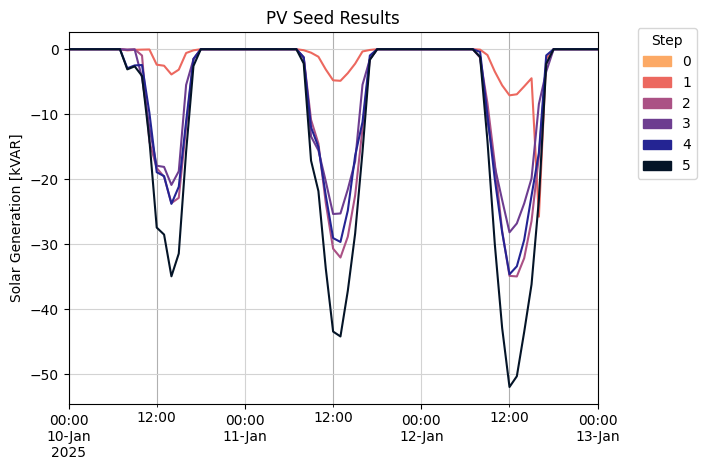

In [36]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='pv_q', use_dt=True, legend_outside=True)

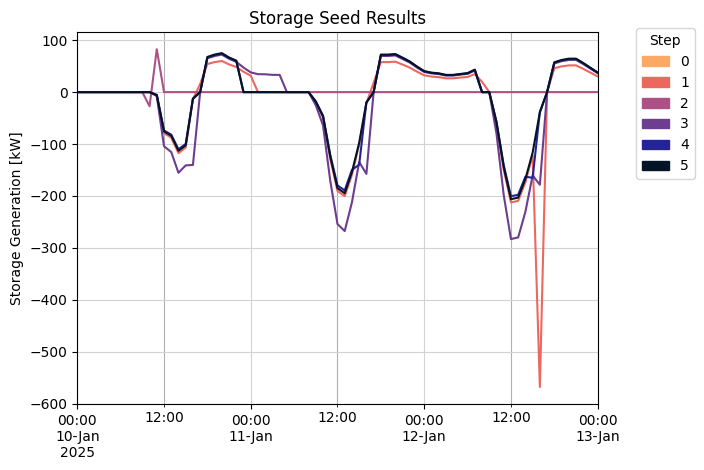

In [37]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='storage_p', use_dt=True, legend_outside=True)

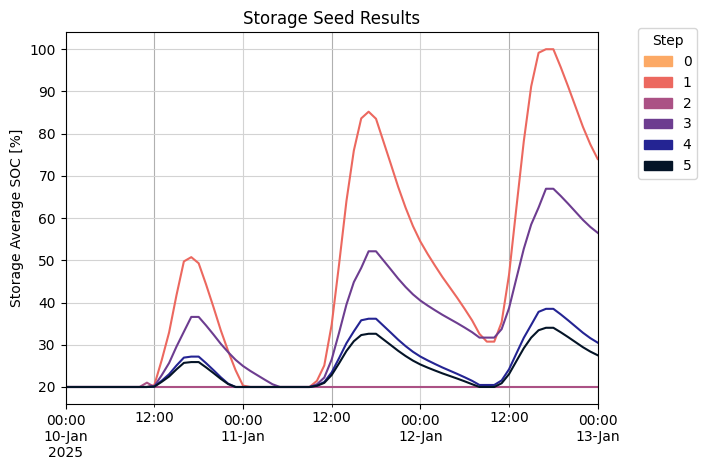

In [38]:
fig, ax = qsts_scenario.seed_results[0].plot(kind='storage_soc', use_dt=True, legend_outside=True)

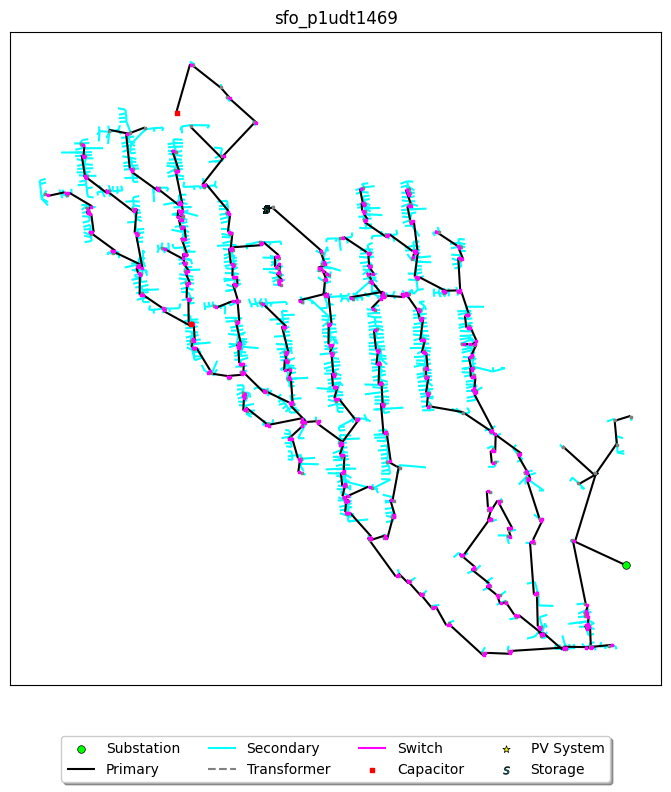

(<Figure size 1100x800 with 1 Axes>, <Axes: title={'center': 'sfo_p1udt1469'}>)

In [39]:
feeder.plot(kind='topo')

NOTE: looks like this violation is due to an issue witht he control?
shouldn't just stop right?

# goto step qsts
accounting for storage behavior may be required, else always re-initialized 


In [40]:
qsts_scenario.go_to_step(step=2, qsts_step=37, update_feeder=True)

In [41]:
feeder.id_violations()['over_capacity']



,Name,Imax,%normal,%emergency,kW,kvar,NumCustomers,TotalCustomers,NumPhases,kVBase,kind,short_name,primary
0,Line.L(R:P1UDT429LV-P1ULV1823),763.677,138.85,127.28,-126.909,68.3130,1,1,3,0.277,Line,L(R:P1UDT429LV-P1ULV1823),False
1,Transformer.TR(R:P1UDT429-P1UDT429LV),29.334,115.20,84.48,-121.270,80.9899,0,1,3,7.200,Transformer,TR(R:P1UDT429-P1UDT429LV),True


In [42]:

line_name = feeder.id_violations()['over_capacity']['Name'][0]
line_name

'Line.L(R:P1UDT429LV-P1ULV1823)'

In [43]:
qsts_scenario.go_to_step(step=3, qsts_step=37, update_feeder=True)

In [44]:

line_mask = feeder.capacity['name'] == line_name.lower().split('.')[-1]
line_mask = feeder.capacity['longname'] == line_name
feeder.capacity[line_mask]

,type,name,imax,%normal,%emergency,kw,kvar,kvbase,numphases,totalcustomers,numcustomers,longname
303,line,l(r:p1udt429lv-p1ulv1823),767.154,139.48,127.86,-255.61,74.5741,0.277,3,1,1,Line.L(R:P1UDT429LV-P1ULV1823)


odd situation where 1 kvar is causing a lot of additional current and overloading...
why?